# 🔬 Comparaison des Algorithmes d'Optimisation pour le Fine-tuning de SLM

**Modèle :** DistilBERT-base-uncased  
**Tâche :** Classification de sentiment (SST-2)  
**Optimiseurs comparés :** AdamW · SGD · Adagrad · RMSprop · AdaFactor  

---
### 🎯 Métriques analysées
| Métrique | Description |
|---|---|
| Loss / Accuracy | Convergence par époque |
| Mémoire GPU | Consommation peak |
| Temps d'entraînement | Secondes par époque |
| F1-score | Qualité finale |
| Sensibilité au LR | Stabilité selon le learning rate |

## 1. Installation des dépendances

In [1]:
# Installation des librairies nécessaires
!pip install -q transformers datasets accelerate evaluate
!pip install -q torch torchvision torchaudio
!pip install -q matplotlib seaborn scikit-learn pandas numpy
!pip install -q optax  # Pour AdaFactor via Optax (optionnel)

# Vérification GPU
import torch
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"✅ Mémoire totale GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00
✅ PyTorch version: 2.11.0+cu128
✅ GPU disponible: True
✅ GPU: Tesla T4
✅ Mémoire totale GPU: 15.64 GB


In [2]:
# ── CORRECTIF : Bug huggingface_hub >= 1.16 avec datasets "glue" ──────────────
!pip install -q "huggingface_hub==1.15.0" "datasets==3.6.0"

# Redémarrer le runtime APRÈS cette cellule :
# Runtime → Restart session  (puis continuer à partir de la cellule suivante)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 19.9 MB/s eta 0:00:00


## 2. Imports et Configuration Globale

In [3]:
import os
import time
import gc
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW, SGD, Adagrad, RMSprop
from torch.optim.lr_scheduler import LinearLR

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    Adafactor
)
from datasets import load_dataset
import evaluate
from sklearn.metrics import classification_report, confusion_matrix

# ── Configuration globale ──────────────────────────────────────────────────────
CONFIG = {
    "model_name": "distilbert-base-uncased",
    "dataset_name": "sst2",
    "max_length": 128,
    "batch_size": 32,
    "num_epochs": 3,
    "num_labels": 2,
    "train_samples": 2000,   # Réduire pour accélérer (mettre None pour tout le dataset)
    "val_samples": 500,
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "warmup_ratio": 0.1,
}

# Learning rates à tester par optimiseur
OPTIMIZER_CONFIGS = {
    "AdamW":    {"lr": 2e-5, "weight_decay": 0.01},
    "SGD":      {"lr": 1e-3, "momentum": 0.9, "weight_decay": 0.01},
    "Adagrad":  {"lr": 1e-3, "weight_decay": 0.01},
    "RMSprop":  {"lr": 1e-4, "weight_decay": 0.01},
    "AdaFactor":{"lr": None, "relative_step": True, "scale_parameter": True},
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])

print(f"🖥️  Device: {CONFIG['device']}")
print(f"📦 Modèle: {CONFIG['model_name']}")
print(f"📊 Optimiseurs: {list(OPTIMIZER_CONFIGS.keys())}")

🖥️  Device: cuda
📦 Modèle: distilbert-base-uncased
📊 Optimiseurs: ['AdamW', 'SGD', 'Adagrad', 'RMSprop', 'AdaFactor']


## 3. Chargement et Préparation des Données (SST-2)

In [4]:
print("📥 Chargement du dataset SST-2...")
# Option A : dataset SST-2 standalone (identique, sans le bug glue)
raw_dataset = load_dataset("stanfordnlp/sst2")

print("\n📊 Structure du dataset:")
print(raw_dataset)

# Aperçu des données
print("\n🔍 Exemples d'entraînement:")
for i in range(3):
    sample = raw_dataset["train"][i]
    sentiment = "POSITIF ✅" if sample["label"] == 1 else "NÉGATIF ❌"
    print(f"  [{sentiment}] {sample['sentence'][:80]}...")

📥 Chargement du dataset SST-2...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]


📊 Structure du dataset:
DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})

🔍 Exemples d'entraînement:
  [NÉGATIF ❌] hide new secretions from the parental units ...
  [NÉGATIF ❌] contains no wit , only labored gags ...
  [POSITIF ✅] that loves its characters and communicates something rather beautiful about huma...


In [5]:
# Chargement du tokenizer
print("🔤 Chargement du tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

def tokenize_function(examples):
    return tokenizer(
        examples["sentence"],
        padding="max_length",
        truncation=True,
        max_length=CONFIG["max_length"]
    )

tokenized_dataset = raw_dataset.map(tokenize_function, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# ← Pas de set_format torch ici, on le fait manuellement dans le DataLoader
from torch.utils.data import Dataset as TorchDataset

class SSTDataset(TorchDataset):
    def __init__(self, hf_dataset):
        self.data = hf_dataset

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data[idx]
        return {
            "input_ids":      torch.tensor(row["input_ids"],      dtype=torch.long),
            "attention_mask": torch.tensor(row["attention_mask"], dtype=torch.long),
            "labels":         torch.tensor(row["labels"],         dtype=torch.long),
        }

def subsample(split, n):
    ds = tokenized_dataset[split]
    if n is not None:
        indices = torch.randperm(len(ds))[:n].tolist()
        ds = ds.select(indices)
    return SSTDataset(ds)

train_dataset = subsample("train",      CONFIG["train_samples"])
val_dataset   = subsample("validation", CONFIG["val_samples"])

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG["batch_size"], shuffle=False)

print(f"✅ Train: {len(train_dataset)} | Val: {len(val_dataset)}")

🔤 Chargement du tokenizer...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

✅ Train: 2000 | Val: 500


## 4. Fonctions d'Entraînement et d'Évaluation

In [6]:
def get_gpu_memory_mb():
    """Retourne la mémoire GPU utilisée en MB."""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1e6
    return 0.0

def reset_gpu_memory():
    """Libère la mémoire GPU."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def get_optimizer(name, model_params):
    """Retourne l'optimiseur configuré selon son nom."""
    cfg = OPTIMIZER_CONFIGS[name]
    if name == "AdamW":
        return AdamW(model_params, lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    elif name == "SGD":
        return SGD(model_params, lr=cfg["lr"],
                   momentum=cfg["momentum"], weight_decay=cfg["weight_decay"])
    elif name == "Adagrad":
        return Adagrad(model_params, lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    elif name == "RMSprop":
        return RMSprop(model_params, lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    elif name == "AdaFactor":
        return Adafactor(
            model_params,
            relative_step=cfg["relative_step"],
            scale_parameter=cfg["scale_parameter"],
            warmup_init=True
        )
    else:
        raise ValueError(f"Optimiseur inconnu: {name}")

def train_one_epoch(model, loader, optimizer, scheduler, device):
    """Entraîne le modèle pour une époque."""
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    batch_losses = []   # ← pour mesurer la stabilité

    start = time.time()

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        # Sauvegarde loss batch
        batch_losses.append(loss.item())

        loss.backward()

        # Gradient clipping pour stabilité
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()

        preds = outputs.logits.argmax(dim=-1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    elapsed = time.time() - start

    # Écart-type de la loss = stabilité
    loss_std = np.std(batch_losses)

    return (
        total_loss / len(loader),
        correct / total,
        elapsed,
        loss_std
           )
@torch.no_grad()
def evaluate_model(model, loader, device):
    """Évalue le modèle sur un DataLoader."""
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)

        total_loss += outputs.loss.item()
        preds = outputs.logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    accuracy = (all_preds == all_labels).mean()

    from sklearn.metrics import f1_score
    f1 = f1_score(all_labels, all_preds, average="binary")

    return total_loss / len(loader), accuracy, f1, all_preds, all_labels
@torch.no_grad()
def measure_inference_time(model, loader, device, num_batches=20):
    """
    Mesure le temps d'inférence pur.
    """
    model.eval()

    times = []

    for i, batch in enumerate(loader):
        if i >= num_batches:
            break

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start = time.time()

        _ = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end = time.time()

        times.append(end - start)

    return np.mean(times) * 1000

print("✅ Fonctions d'entraînement et d'évaluation définies.")

✅ Fonctions d'entraînement et d'évaluation définies.


## 5. Boucle d'Expérimentation Principale

> ⏱️ **Durée estimée :** ~15-25 min sur Google Colab GPU T4 avec 2000 exemples d'entraînement

In [7]:
# Dictionnaire pour stocker tous les résultats
RESULTS = {}

for opt_name in OPTIMIZER_CONFIGS.keys():
    print(f"\n{'='*60}")
    print(f"🚀 Optimiseur: {opt_name}")
    print(f"{'='*60}")

    # Initialisation
    reset_gpu_memory()

    # Charger un modèle frais à chaque fois
    model = AutoModelForSequenceClassification.from_pretrained(
        CONFIG["model_name"],
        num_labels=CONFIG["num_labels"]
    )
    model = model.to(CONFIG["device"])

    # Mémoire après chargement du modèle
    mem_model = get_gpu_memory_mb()
    print(f"   📦 Mémoire après chargement modèle: {mem_model:.1f} MB")

    # Optimiseur
    optimizer = get_optimizer(opt_name, model.parameters())

    # Scheduler (non applicable pour AdaFactor avec relative_step)
    total_steps = len(train_loader) * CONFIG["num_epochs"]
    warmup_steps = int(total_steps * CONFIG["warmup_ratio"])

    if opt_name != "AdaFactor":
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
    else:
        scheduler = None

    # Historique des métriques
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [], "val_f1": [],
        "epoch_time": [], "peak_memory_mb": [],"loss_std": []
    }

    total_train_time = 0

    for epoch in range(CONFIG["num_epochs"]):
        print(f"\n   📍 Époque {epoch+1}/{CONFIG['num_epochs']}")

        # Entraînement
        train_loss, train_acc, epoch_time, loss_std = train_one_epoch(
        model, train_loader, optimizer, scheduler, CONFIG["device"]
        )
        # Pic mémoire
        if torch.cuda.is_available():
            peak_mem = torch.cuda.max_memory_allocated() / 1e6
        else:
            peak_mem = 0.0

        # Évaluation
        val_loss, val_acc, val_f1, _, _ = evaluate_model(
            model, val_loader, CONFIG["device"]
        )

        total_train_time += epoch_time

        # Sauvegarde métriques
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["epoch_time"].append(epoch_time)
        history["loss_std"].append(loss_std)
        history["peak_memory_mb"].append(peak_mem)

        print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"   Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | F1: {val_f1:.4f}")
        print(f"   ⏱️  Temps époque: {epoch_time:.1f}s | 💾 Mémoire peak: {peak_mem:.1f} MB")

    # Prédictions finales pour la matrice de confusion
    _, final_acc, final_f1, final_preds, final_labels = evaluate_model(
        model, val_loader, CONFIG["device"]
    )
    inference_time_ms = measure_inference_time(
    model,
    val_loader,
    CONFIG["device"]
    )

    print(f"⚡ Temps d'inférence moyen : {inference_time_ms:.2f} ms")

    RESULTS[opt_name] = {
    "avg_loss_std": np.mean(history["loss_std"]),
    "inference_time_ms": inference_time_ms,
    "history": history,
    "final_acc": final_acc,
    "final_f1": final_f1,
    "total_time": total_train_time,
    "avg_peak_memory": np.mean(history["peak_memory_mb"]),
    "inference_time_ms": inference_time_ms,
    "final_preds": final_preds,
    "final_labels": final_labels,
}

    print(f"\n   ✅ {opt_name} terminé | Acc finale: {final_acc:.4f} | F1: {final_f1:.4f}")
    print(f"   ⏱️  Temps total: {total_train_time:.1f}s | 💾 Mémoire moy: {np.mean(history['peak_memory_mb']):.1f} MB")

    # Libérer la mémoire
    del model, optimizer
    reset_gpu_memory()

print(f"\n{'='*60}")
print("🎉 Toutes les expériences sont terminées !")
print(f"{'='*60}")


🚀 Optimiseur: AdamW


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   📦 Mémoire après chargement modèle: 269.0 MB

   📍 Époque 1/3
   Train Loss: 0.5469 | Train Acc: 0.6995
   Val   Loss: 0.3510 | Val   Acc: 0.8440 | F1: 0.8446
   ⏱️  Temps époque: 20.0s | 💾 Mémoire peak: 2197.8 MB

   📍 Époque 2/3
   Train Loss: 0.2748 | Train Acc: 0.9005
   Val   Loss: 0.3713 | Val   Acc: 0.8360 | F1: 0.8441
   ⏱️  Temps époque: 18.9s | 💾 Mémoire peak: 2197.8 MB

   📍 Époque 3/3
   Train Loss: 0.1950 | Train Acc: 0.9390
   Val   Loss: 0.3806 | Val   Acc: 0.8400 | F1: 0.8496
   ⏱️  Temps époque: 19.4s | 💾 Mémoire peak: 2197.8 MB
⚡ Temps d'inférence moyen : 90.58 ms

   ✅ AdamW terminé | Acc finale: 0.8400 | F1: 0.8496
   ⏱️  Temps total: 58.2s | 💾 Mémoire moy: 2197.8 MB

🚀 Optimiseur: SGD


...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   📦 Mémoire après chargement modèle: 1107.8 MB

   📍 Époque 1/3
   Train Loss: 0.5337 | Train Acc: 0.7265
   Val   Loss: 0.4873 | Val   Acc: 0.7720 | F1: 0.8048
   ⏱️  Temps époque: 20.5s | 💾 Mémoire peak: 1918.3 MB

   📍 Époque 2/3
   Train Loss: 0.3285 | Train Acc: 0.8600
   Val   Loss: 0.4203 | Val   Acc: 0.7980 | F1: 0.8206
   ⏱️  Temps époque: 21.6s | 💾 Mémoire peak: 1918.3 MB

   📍 Époque 3/3
   Train Loss: 0.1755 | Train Acc: 0.9345
   Val   Loss: 0.3629 | Val   Acc: 0.8640 | F1: 0.8612
   ⏱️  Temps époque: 20.7s | 💾 Mémoire peak: 1918.3 MB
⚡ Temps d'inférence moyen : 97.02 ms

   ✅ RMSprop terminé | Acc finale: 0.8640 | F1: 0.8612
   ⏱️  Temps total: 62.8s | 💾 Mémoire moy: 1918.3 MB

🚀 Optimiseur: AdaFactor


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   📦 Mémoire après chargement modèle: 1114.0 MB

   📍 Époque 1/3
   Train Loss: 0.6887 | Train Acc: 0.5460
   Val   Loss: 0.6923 | Val   Acc: 0.4880 | F1: 0.6550
   ⏱️  Temps époque: 24.8s | 💾 Mémoire peak: 1639.3 MB

   📍 Époque 2/3
   Train Loss: 0.6550 | Train Acc: 0.5900
   Val   Loss: 0.6038 | Val   Acc: 0.6300 | F1: 0.7218
   ⏱️  Temps époque: 23.9s | 💾 Mémoire peak: 1639.3 MB

   📍 Époque 3/3
   Train Loss: 0.4547 | Train Acc: 0.8265
   Val   Loss: 0.3722 | Val   Acc: 0.8500 | F1: 0.8466
   ⏱️  Temps époque: 22.6s | 💾 Mémoire peak: 1639.3 MB
⚡ Temps d'inférence moyen : 97.24 ms

   ✅ AdaFactor terminé | Acc finale: 0.8500 | F1: 0.8466
   ⏱️  Temps total: 71.3s | 💾 Mémoire moy: 1639.3 MB

🎉 Toutes les expériences sont terminées !


## 6. Tableau Récapitulatif des Résultats

In [8]:
rows = []
for opt_name, res in RESULTS.items():
    h = res["history"]
    rows.append({
        "Optimiseur": opt_name,
        "Accuracy Finale": f"{res['final_acc']:.4f}",
        "F1-Score Final": f"{res['final_f1']:.4f}",
        "Val Loss Min": f"{min(h['val_loss']):.4f}",
        "Temps Total (s)": f"{res['total_time']:.1f}",
        "Mémoire Peak Moy (MB)": f"{res['avg_peak_memory']:.1f}",
        "Temps Inférence (ms)": f"{res['inference_time_ms']:.2f}",
        "Stabilité (std loss)": f"{res['avg_loss_std']:.4f}",
        "Convergence (val_acc E1→E3)": f"{h['val_acc'][0]:.3f} → {h['val_acc'][-1]:.3f}",
    })

df_results = pd.DataFrame(rows)
df_results = df_results.sort_values("F1-Score Final", ascending=False).reset_index(drop=True)

print("\n📊 Tableau Comparatif des Optimiseurs")
print("=" * 130)
print(df_results.to_string(index=False))
print("=" * 130)


📊 Tableau Comparatif des Optimiseurs
Optimiseur Accuracy Finale F1-Score Final Val Loss Min Temps Total (s) Mémoire Peak Moy (MB) Temps Inférence (ms) Stabilité (std loss) Convergence (val_acc E1→E3)
   RMSprop          0.8640         0.8612       0.3629            62.8                1918.3                97.02               0.0991               0.772 → 0.864
   Adagrad          0.8580         0.8588       0.3114            62.9                1906.1                96.33               0.1165               0.862 → 0.858
     AdamW          0.8400         0.8496       0.3510            58.2                2197.8                90.58               0.1048               0.844 → 0.840
 AdaFactor          0.8500         0.8466       0.3722            71.3                1639.3                97.24               0.0453               0.488 → 0.850
       SGD          0.8040         0.8192       0.5691            60.9                1917.9                96.25               0.0320             

## 7. Visualisations Complètes

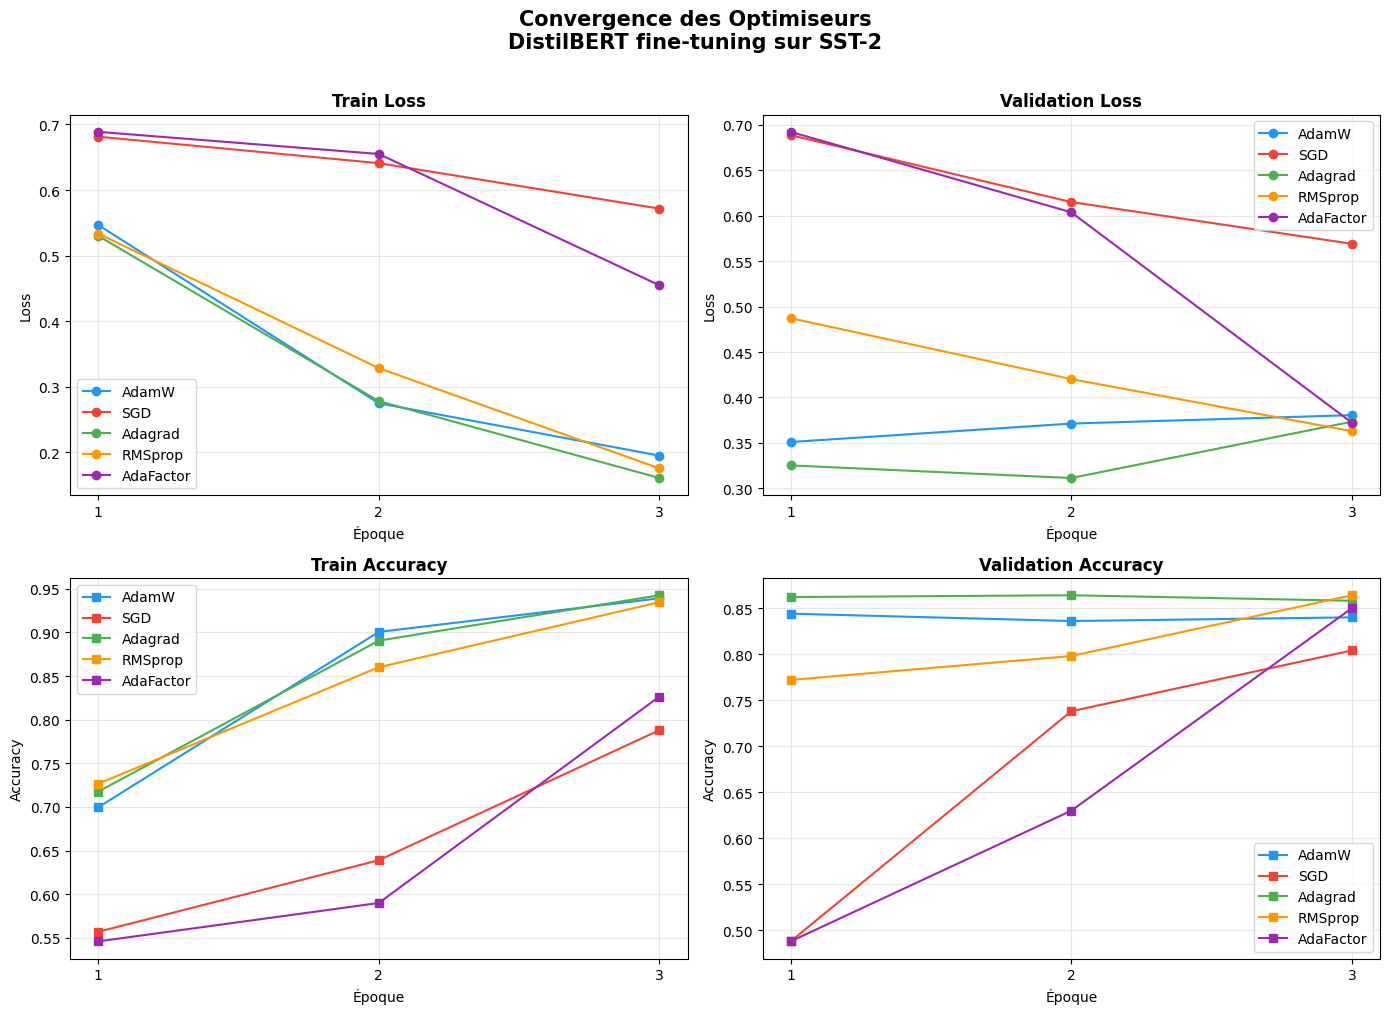

✅ Figure 1 sauvegardée.


In [9]:
# Palette de couleurs
COLORS = {
    "AdamW":    "#2196F3",
    "SGD":      "#F44336",
    "Adagrad":  "#4CAF50",
    "RMSprop":  "#FF9800",
    "AdaFactor":"#9C27B0",
}
epochs = list(range(1, CONFIG["num_epochs"] + 1))

# ── Figure 1 : Loss et Accuracy ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Convergence des Optimiseurs\nDistilBERT fine-tuning sur SST-2",
             fontsize=15, fontweight="bold", y=1.01)

for opt_name, res in RESULTS.items():
    h   = res["history"]
    col = COLORS[opt_name]

    axes[0, 0].plot(epochs, h["train_loss"], marker="o", color=col, label=opt_name)
    axes[0, 1].plot(epochs, h["val_loss"],   marker="o", color=col, label=opt_name)
    axes[1, 0].plot(epochs, h["train_acc"],  marker="s", color=col, label=opt_name)
    axes[1, 1].plot(epochs, h["val_acc"],    marker="s", color=col, label=opt_name)

titles = ["Train Loss", "Validation Loss", "Train Accuracy", "Validation Accuracy"]
ylabels = ["Loss", "Loss", "Accuracy", "Accuracy"]

for ax, title, ylabel in zip(axes.flat, titles, ylabels):
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Époque")
    ax.set_ylabel(ylabel)
    ax.set_xticks(epochs)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig1_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 1 sauvegardée.")

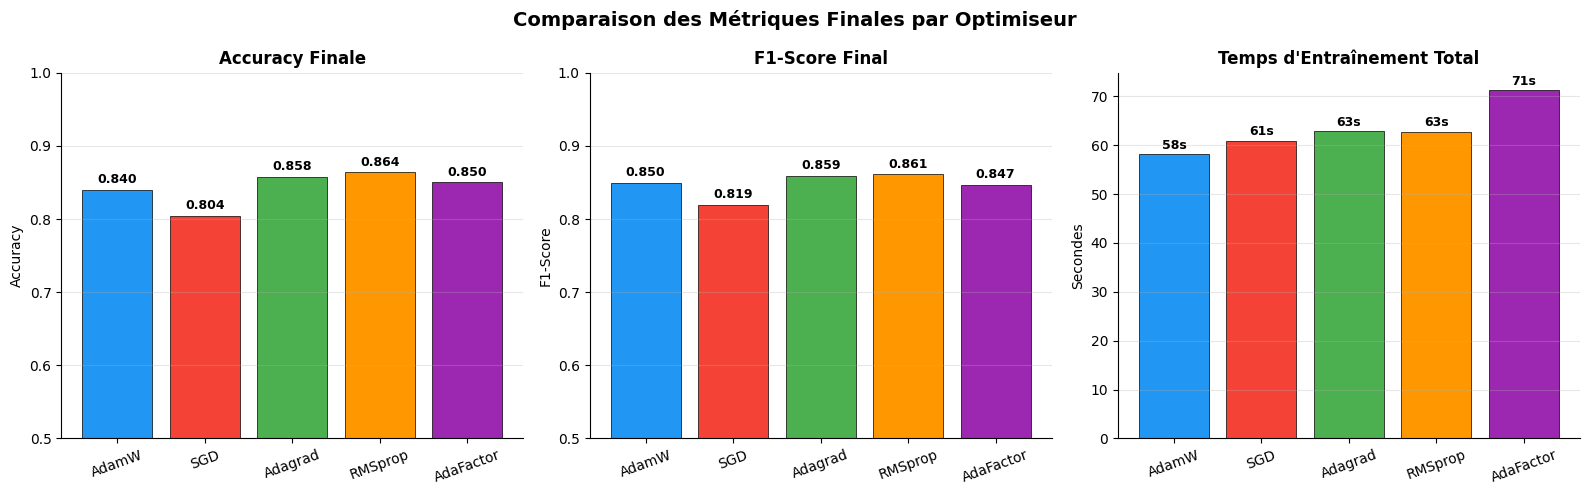

✅ Figure 2 sauvegardée.


In [10]:
# ── Figure 2 : Métriques Finales ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Comparaison des Métriques Finales par Optimiseur",
             fontsize=14, fontweight="bold")

opt_names    = list(RESULTS.keys())
colors_list  = [COLORS[n] for n in opt_names]

accuracies   = [RESULTS[n]["final_acc"]         for n in opt_names]
f1_scores    = [RESULTS[n]["final_f1"]          for n in opt_names]
total_times  = [RESULTS[n]["total_time"]        for n in opt_names]
peak_mems    = [RESULTS[n]["avg_peak_memory"]   for n in opt_names]

# Accuracy
bars0 = axes[0].bar(opt_names, accuracies, color=colors_list, edgecolor="black", linewidth=0.5)
axes[0].set_title("Accuracy Finale", fontweight="bold")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.5, 1.0)
axes[0].tick_params(axis="x", rotation=20)
for bar, val in zip(bars0, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# F1-Score
bars1 = axes[1].bar(opt_names, f1_scores, color=colors_list, edgecolor="black", linewidth=0.5)
axes[1].set_title("F1-Score Final", fontweight="bold")
axes[1].set_ylabel("F1-Score")
axes[1].set_ylim(0.5, 1.0)
axes[1].tick_params(axis="x", rotation=20)
for bar, val in zip(bars1, f1_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# Temps total
bars2 = axes[2].bar(opt_names, total_times, color=colors_list, edgecolor="black", linewidth=0.5)
axes[2].set_title("Temps d'Entraînement Total", fontweight="bold")
axes[2].set_ylabel("Secondes")
axes[2].tick_params(axis="x", rotation=20)
for bar, val in zip(bars2, total_times):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.0f}s", ha="center", va="bottom", fontsize=9, fontweight="bold")

for ax in axes:
    ax.grid(axis="y", alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig2_final_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 2 sauvegardée.")

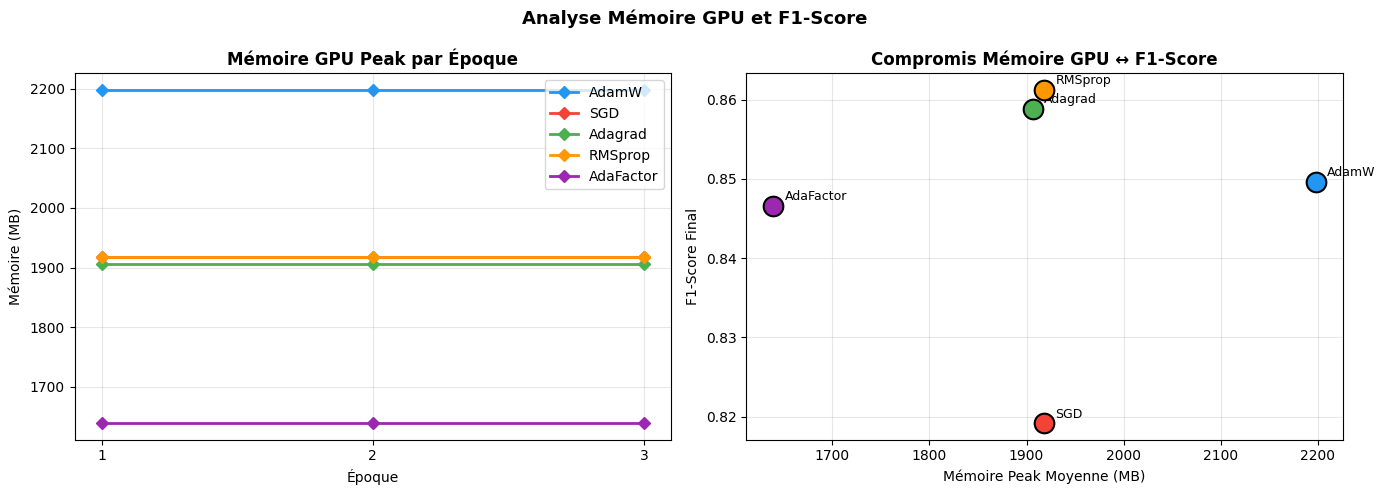

✅ Figure 3 sauvegardée.


In [11]:
# ── Figure 3 : Mémoire GPU ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Analyse Mémoire GPU et F1-Score", fontsize=13, fontweight="bold")

# Mémoire par époque
for opt_name, res in RESULTS.items():
    h = res["history"]
    axes[0].plot(epochs, h["peak_memory_mb"], marker="D",
                 color=COLORS[opt_name], label=opt_name, linewidth=2)

axes[0].set_title("Mémoire GPU Peak par Époque", fontweight="bold")
axes[0].set_xlabel("Époque")
axes[0].set_ylabel("Mémoire (MB)")
axes[0].set_xticks(epochs)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter : Mémoire vs F1
for opt_name, res in RESULTS.items():
    axes[1].scatter(
        res["avg_peak_memory"], res["final_f1"],
        color=COLORS[opt_name], s=200, label=opt_name,
        edgecolors="black", linewidths=1.5, zorder=5
    )
    axes[1].annotate(
        opt_name,
        (res["avg_peak_memory"], res["final_f1"]),
        textcoords="offset points", xytext=(8, 4), fontsize=9
    )

axes[1].set_title("Compromis Mémoire GPU ↔ F1-Score", fontweight="bold")
axes[1].set_xlabel("Mémoire Peak Moyenne (MB)")
axes[1].set_ylabel("F1-Score Final")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig3_memory.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 3 sauvegardée.")

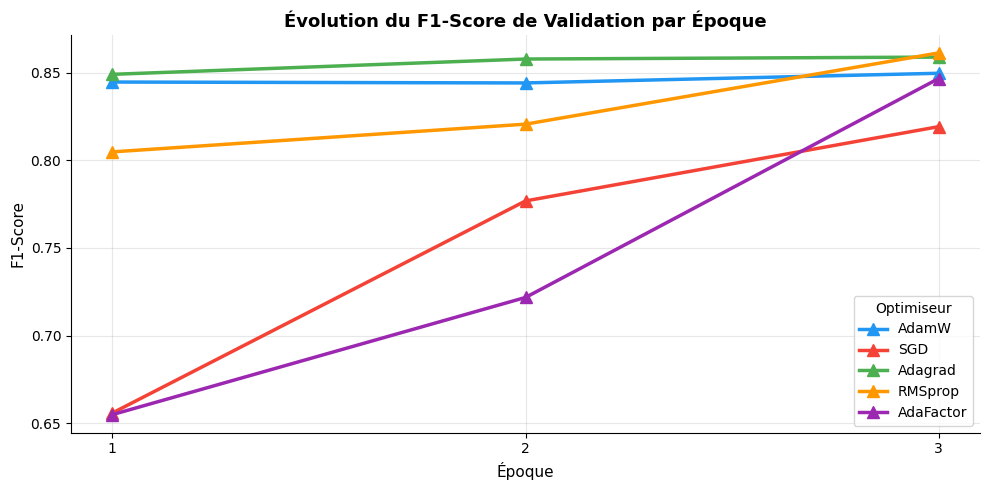

✅ Figure 4 sauvegardée.


In [12]:
# ── Figure 4 : Évolution du F1-Score ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for opt_name, res in RESULTS.items():
    h = res["history"]
    ax.plot(epochs, h["val_f1"], marker="^", linewidth=2.5,
            color=COLORS[opt_name], label=opt_name, markersize=8)

ax.set_title("Évolution du F1-Score de Validation par Époque",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Époque", fontsize=11)
ax.set_ylabel("F1-Score", fontsize=11)
ax.set_xticks(epochs)
ax.legend(title="Optimiseur", fontsize=10)
ax.grid(alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig4_f1_progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 4 sauvegardée.")

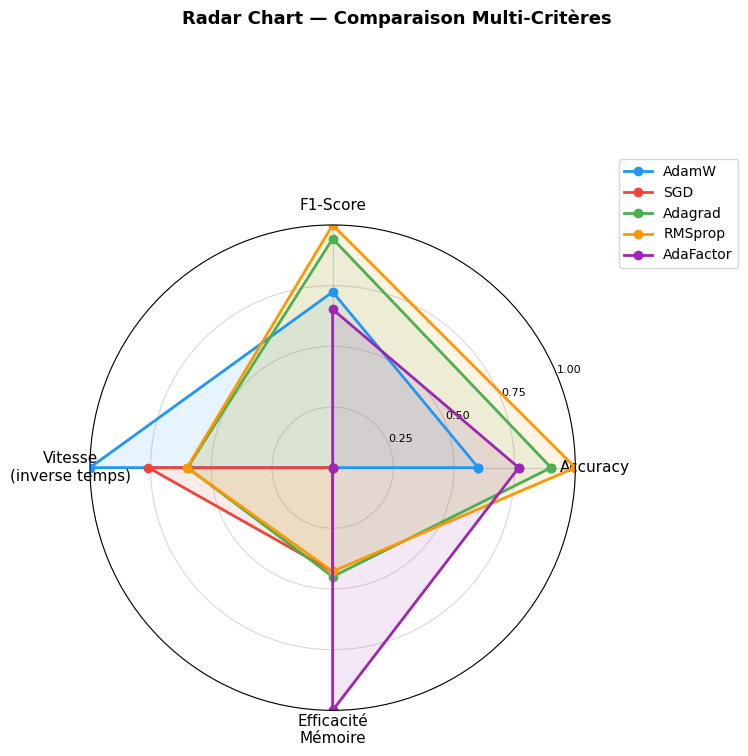

✅ Figure 5 sauvegardée.


In [13]:
# ── Figure 5 : Radar Chart (Spider Plot) ─────────────────────────────────────
from matplotlib.patches import FancyArrowPatch

categories = ["Accuracy", "F1-Score", "Vitesse\n(inverse temps)", "Efficacité\nMémoire"]
N = len(categories)

# Normalisation des métriques (0–1, 1 = meilleur)
def normalize(values):
    vmin, vmax = min(values), max(values)
    if vmax == vmin:
        return [0.5] * len(values)
    return [(v - vmin) / (vmax - vmin) for v in values]

accs  = normalize([RESULTS[n]["final_acc"] for n in opt_names])
f1s   = normalize([RESULTS[n]["final_f1"] for n in opt_names])
# Vitesse : inverse du temps (plus c'est rapide = meilleur)
times = normalize([1 / RESULTS[n]["total_time"] for n in opt_names])
# Efficacité mémoire : inverse de la mémoire
mems  = normalize([1 / (RESULTS[n]["avg_peak_memory"] + 1) for n in opt_names])

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Fermeture du polygone

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle("Radar Chart — Comparaison Multi-Critères",
             fontsize=13, fontweight="bold", y=1.02)

for i, (opt_name, acc, f1, spd, mem) in enumerate(zip(opt_names, accs, f1s, times, mems)):
    values = [acc, f1, spd, mem]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, color=COLORS[opt_name], label=opt_name)
    ax.fill(angles, values, alpha=0.1, color=COLORS[opt_name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=8)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(color="gray", alpha=0.3)

plt.tight_layout()
plt.savefig("fig5_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 5 sauvegardée.")

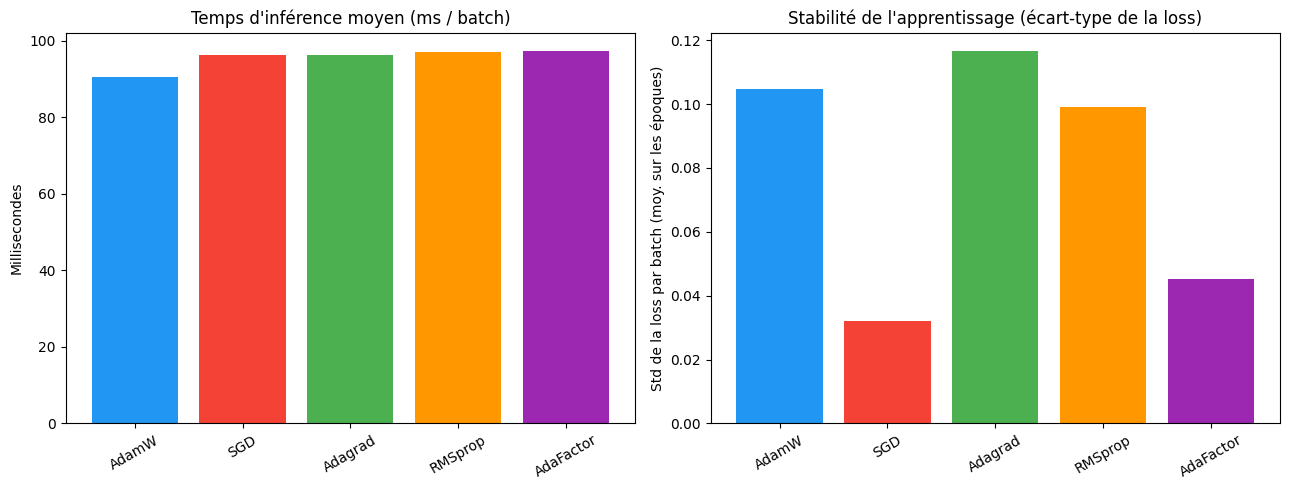

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

opt_names = list(RESULTS.keys())
inf_times = [RESULTS[o]["inference_time_ms"] for o in opt_names]
stabs     = [RESULTS[o]["avg_loss_std"] for o in opt_names]
bar_colors = [COLORS.get(o, "#888888") for o in opt_names]

axes[0].bar(opt_names, inf_times, color=bar_colors)
axes[0].set_title("Temps d'inférence moyen (ms / batch)")
axes[0].set_ylabel("Millisecondes")
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(opt_names, stabs, color=bar_colors)
axes[1].set_title("Stabilité de l'apprentissage (écart-type de la loss)")
axes[1].set_ylabel("Std de la loss par batch (moy. sur les époques)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 8. Analyse de Sensibilité au Learning Rate

On teste AdamW et SGD avec plusieurs learning rates pour comprendre leur sensibilité.

In [15]:
# Optimiseurs et LR à tester
LR_SENSITIVITY = {
    "AdamW": [1e-6, 5e-6, 2e-5, 5e-5, 1e-4],
    "SGD":   [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
}

lr_results = {"AdamW": [], "SGD": []}

# 1 seule époque pour l'analyse rapide
N_EPOCHS_LR = 1
TRAIN_SAMPLES_LR = 500  # Petit sous-ensemble

small_train = subsample("train", TRAIN_SAMPLES_LR)
small_loader = DataLoader(small_train, batch_size=CONFIG["batch_size"], shuffle=True)

for opt_name, lr_list in LR_SENSITIVITY.items():
    print(f"\n🔍 Sensibilité au LR — {opt_name}")
    for lr in lr_list:
        reset_gpu_memory()
        model = AutoModelForSequenceClassification.from_pretrained(
            CONFIG["model_name"], num_labels=CONFIG["num_labels"]
        ).to(CONFIG["device"])

        if opt_name == "AdamW":
            opt = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
        else:
            opt = SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=0.01)

        train_loss, train_acc, _, _ = train_one_epoch(
          model, small_loader, opt, None, CONFIG["device"]
        )
        _, val_acc, val_f1, _, _ = evaluate_model(model, val_loader, CONFIG["device"])

        lr_results[opt_name].append({
            "lr": lr, "train_loss": train_loss,
            "val_acc": val_acc, "val_f1": val_f1
        })
        print(f"   LR={lr:.0e} | Train Loss={train_loss:.4f} | Val Acc={val_acc:.4f} | F1={val_f1:.4f}")

        del model, opt
        reset_gpu_memory()

print("\n✅ Analyse de sensibilité terminée.")


🔍 Sensibilité au LR — AdamW


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   LR=1e-06 | Train Loss=0.6931 | Val Acc=0.5960 | F1=0.3648


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   LR=1e-02 | Train Loss=0.6937 | Val Acc=0.5160 | F1=0.0163


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


   LR=1e-01 | Train Loss=0.8396 | Val Acc=0.4880 | F1=0.6559

✅ Analyse de sensibilité terminée.


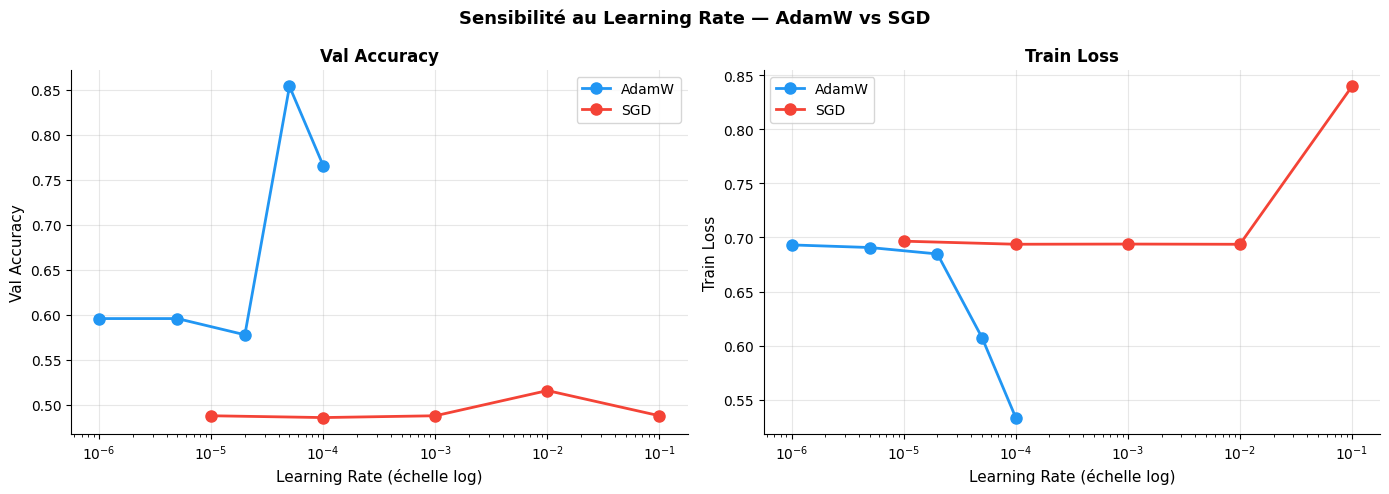

✅ Figure 6 sauvegardée.


In [16]:
# ── Figure 6 : Sensibilité au Learning Rate ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sensibilité au Learning Rate — AdamW vs SGD",
             fontsize=13, fontweight="bold")

for ax, metric, ylabel in zip(axes, ["val_acc", "train_loss"], ["Val Accuracy", "Train Loss"]):
    for opt_name, color in [("AdamW", COLORS["AdamW"]), ("SGD", COLORS["SGD"])]:
        data = lr_results[opt_name]
        lrs  = [d["lr"] for d in data]
        vals = [d[metric] for d in data]
        ax.semilogx(lrs, vals, marker="o", color=color, label=opt_name,
                    linewidth=2, markersize=8)

    ax.set_xlabel("Learning Rate (échelle log)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("fig6_lr_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 6 sauvegardée.")

## 9. Matrices de Confusion

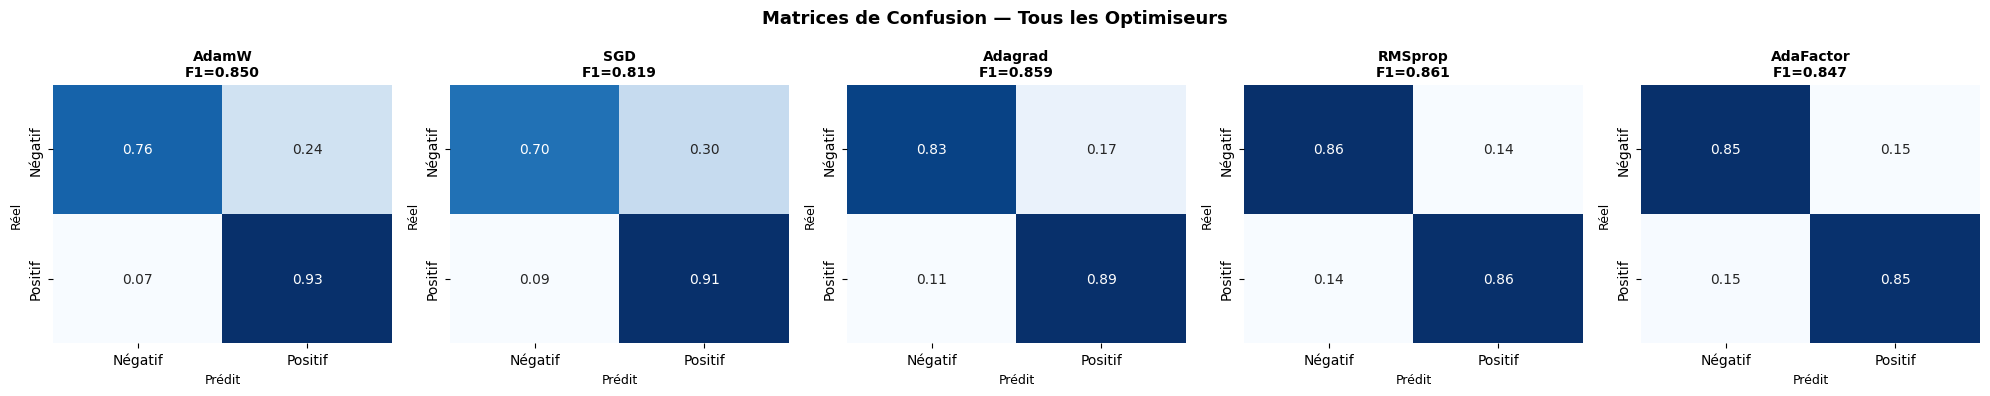

✅ Figure 7 sauvegardée.


In [17]:
from sklearn.metrics import confusion_matrix
import itertools

n_opts = len(RESULTS)
fig, axes = plt.subplots(1, n_opts, figsize=(4 * n_opts, 4))
fig.suptitle("Matrices de Confusion — Tous les Optimiseurs",
             fontsize=13, fontweight="bold")

class_names = ["Négatif", "Positif"]

for ax, (opt_name, res) in zip(axes, RESULTS.items()):
    cm = confusion_matrix(res["final_labels"], res["final_preds"])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        ax=ax, cbar=False,
        xticklabels=class_names, yticklabels=class_names
    )
    ax.set_title(f"{opt_name}\nF1={res['final_f1']:.3f}",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("Prédit", fontsize=9)
    ax.set_ylabel("Réel", fontsize=9)

plt.tight_layout()
plt.savefig("fig7_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 7 sauvegardée.")

## 10. Analyse de Généralisation


📊 Analyse du Gap de Généralisation (Train Acc - Val Acc)
AdamW        | Gap moyen: +0.0063  (bonne généralisation)
SGD          | Gap moyen: -0.0153  (bonne généralisation)
Adagrad      | Gap moyen: -0.0112  (bonne généralisation)
RMSprop      | Gap moyen: +0.0290  (bonne généralisation)
AdaFactor    | Gap moyen: -0.0018  (bonne généralisation)


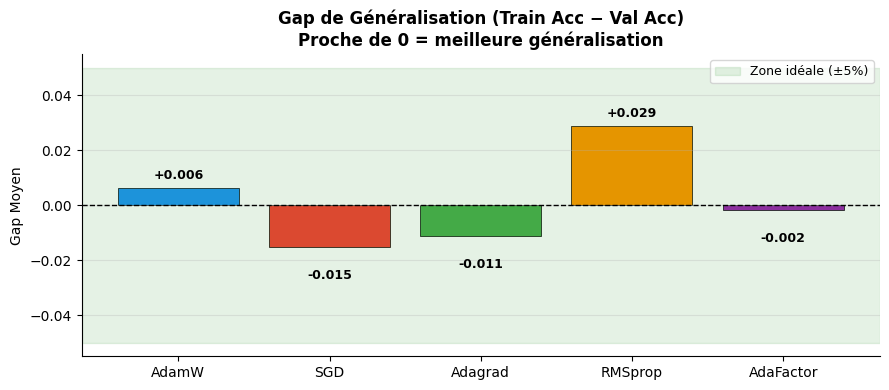

✅ Figure 8 sauvegardée.


In [18]:
# Gap de généralisation : différence entre train accuracy et val accuracy
print("\n📊 Analyse du Gap de Généralisation (Train Acc - Val Acc)")
print("=" * 55)

generalization_gaps = {}

for opt_name, res in RESULTS.items():
    h = res["history"]
    gaps = [ta - va for ta, va in zip(h["train_acc"], h["val_acc"])]
    avg_gap = np.mean(gaps)
    generalization_gaps[opt_name] = avg_gap

    print(f"{opt_name:12s} | Gap moyen: {avg_gap:+.4f} ",
          "(léger surapprentissage)" if avg_gap > 0.05
          else "(bonne généralisation)" if abs(avg_gap) <= 0.05
          else "(sous-apprentissage)")

# Visualisation
fig, ax = plt.subplots(figsize=(9, 4))

gap_values = [generalization_gaps[n] for n in opt_names]
bars = ax.bar(opt_names, gap_values,
              color=[COLORS[n] for n in opt_names],
              edgecolor="black", linewidth=0.5)

ax.axhline(y=0, color="black", linewidth=1, linestyle="--")
ax.axhspan(-0.05, 0.05, alpha=0.1, color="green", label="Zone idéale (±5%)")

ax.set_title("Gap de Généralisation (Train Acc − Val Acc)\n"
             "Proche de 0 = meilleure généralisation",
             fontweight="bold", fontsize=12)
ax.set_ylabel("Gap Moyen")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, val in zip(bars, gap_values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.002 if val >= 0 else -0.008),
            f"{val:+.3f}", ha="center", va="bottom" if val >= 0 else "top",
            fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("fig8_generalization.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 8 sauvegardée.")

## 11. Dashboard Final Récapitulatif

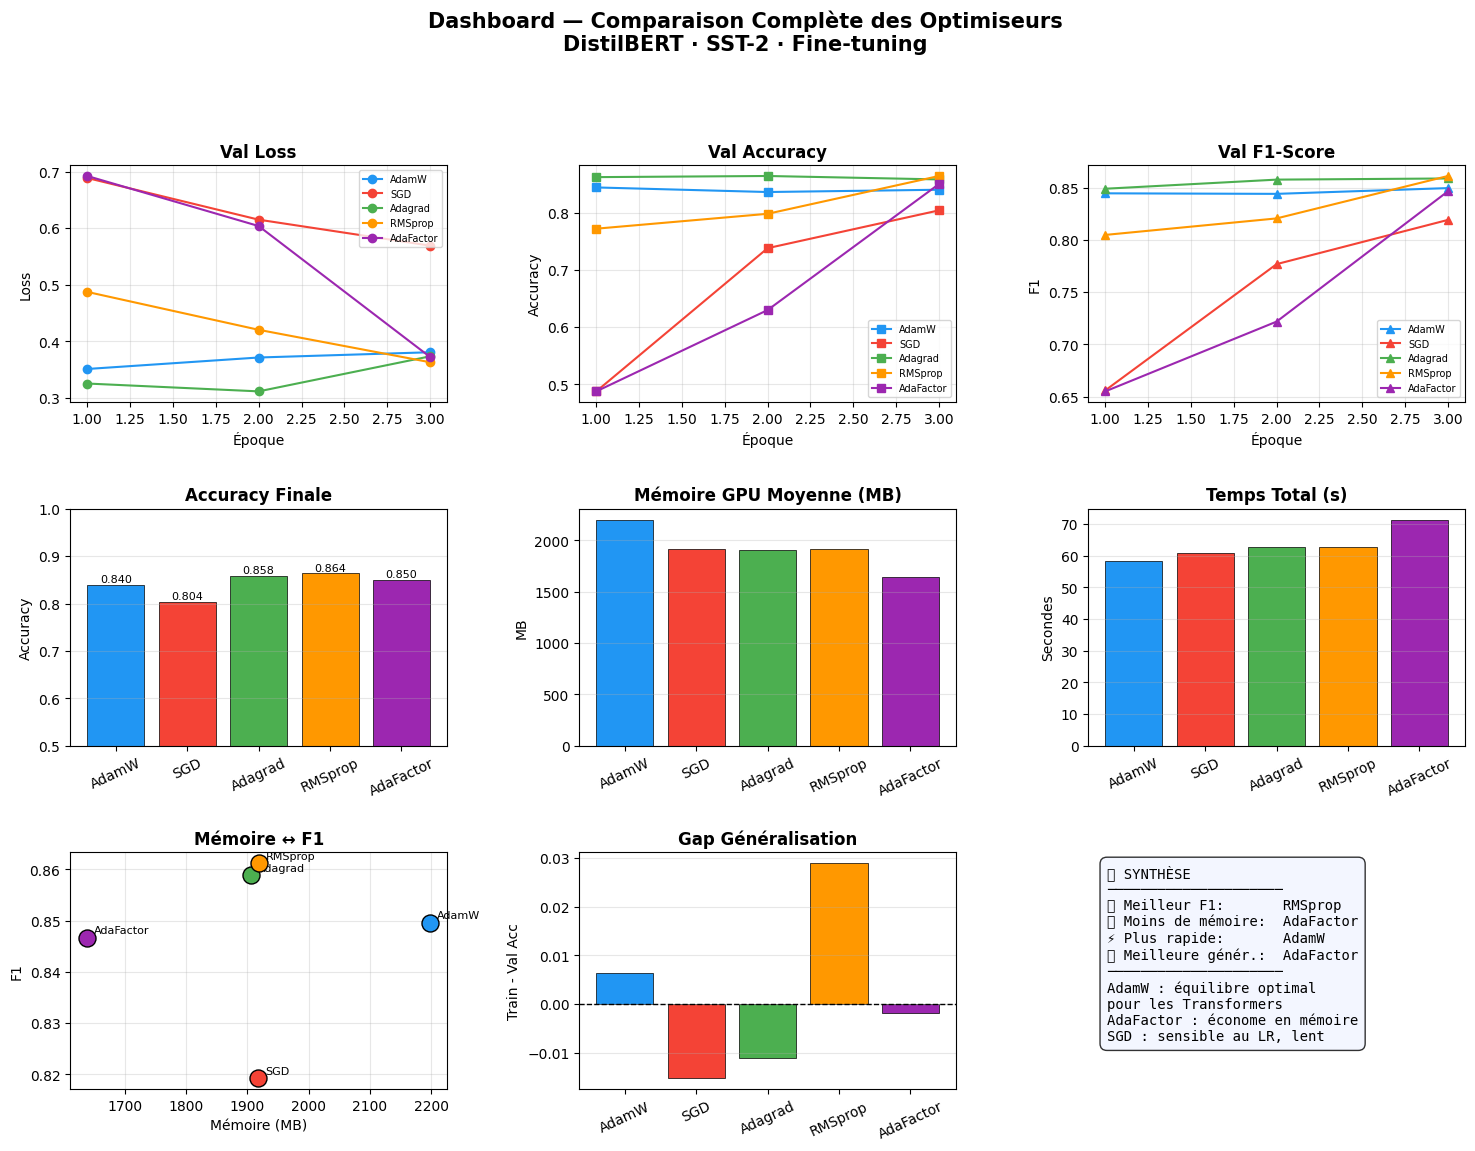

✅ Dashboard final sauvegardé.


In [19]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(
    "Dashboard — Comparaison Complète des Optimiseurs\nDistilBERT · SST-2 · Fine-tuning",
    fontsize=15, fontweight="bold", y=1.01
)

# ① Val Loss
ax1 = fig.add_subplot(gs[0, 0])
for opt_name, res in RESULTS.items():
    ax1.plot(epochs, res["history"]["val_loss"],
             marker="o", color=COLORS[opt_name], label=opt_name)
ax1.set_title("Val Loss", fontweight="bold")
ax1.set_xlabel("Époque"); ax1.set_ylabel("Loss")
ax1.legend(fontsize=7); ax1.grid(alpha=0.3)

# ② Val Accuracy
ax2 = fig.add_subplot(gs[0, 1])
for opt_name, res in RESULTS.items():
    ax2.plot(epochs, res["history"]["val_acc"],
             marker="s", color=COLORS[opt_name], label=opt_name)
ax2.set_title("Val Accuracy", fontweight="bold")
ax2.set_xlabel("Époque"); ax2.set_ylabel("Accuracy")
ax2.legend(fontsize=7); ax2.grid(alpha=0.3)

# ③ F1-Score
ax3 = fig.add_subplot(gs[0, 2])
for opt_name, res in RESULTS.items():
    ax3.plot(epochs, res["history"]["val_f1"],
             marker="^", color=COLORS[opt_name], label=opt_name)
ax3.set_title("Val F1-Score", fontweight="bold")
ax3.set_xlabel("Époque"); ax3.set_ylabel("F1")
ax3.legend(fontsize=7); ax3.grid(alpha=0.3)

# ④ Accuracy Finale
ax4 = fig.add_subplot(gs[1, 0])
bars4 = ax4.bar(opt_names, [RESULTS[n]["final_acc"] for n in opt_names],
                color=[COLORS[n] for n in opt_names], edgecolor="black", linewidth=0.5)
ax4.set_title("Accuracy Finale", fontweight="bold")
ax4.set_ylabel("Accuracy"); ax4.set_ylim(0.5, 1.0)
ax4.tick_params(axis="x", rotation=25)
for bar, val in zip(bars4, [RESULTS[n]["final_acc"] for n in opt_names]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.3f}", ha="center", fontsize=8)
ax4.grid(axis="y", alpha=0.3)

# ⑤ Mémoire GPU
ax5 = fig.add_subplot(gs[1, 1])
bars5 = ax5.bar(opt_names, [RESULTS[n]["avg_peak_memory"] for n in opt_names],
                color=[COLORS[n] for n in opt_names], edgecolor="black", linewidth=0.5)
ax5.set_title("Mémoire GPU Moyenne (MB)", fontweight="bold")
ax5.set_ylabel("MB")
ax5.tick_params(axis="x", rotation=25)
ax5.grid(axis="y", alpha=0.3)

# ⑥ Temps d'entraînement
ax6 = fig.add_subplot(gs[1, 2])
bars6 = ax6.bar(opt_names, [RESULTS[n]["total_time"] for n in opt_names],
                color=[COLORS[n] for n in opt_names], edgecolor="black", linewidth=0.5)
ax6.set_title("Temps Total (s)", fontweight="bold")
ax6.set_ylabel("Secondes")
ax6.tick_params(axis="x", rotation=25)
ax6.grid(axis="y", alpha=0.3)

# ⑦ Scatter mémoire vs F1
ax7 = fig.add_subplot(gs[2, 0])
for opt_name, res in RESULTS.items():
    ax7.scatter(res["avg_peak_memory"], res["final_f1"],
                color=COLORS[opt_name], s=150, label=opt_name,
                edgecolors="black", linewidths=1, zorder=5)
    ax7.annotate(opt_name, (res["avg_peak_memory"], res["final_f1"]),
                 textcoords="offset points", xytext=(5, 3), fontsize=8)
ax7.set_title("Mémoire ↔ F1", fontweight="bold")
ax7.set_xlabel("Mémoire (MB)"); ax7.set_ylabel("F1")
ax7.grid(alpha=0.3)

# ⑧ Gap de généralisation
ax8 = fig.add_subplot(gs[2, 1])
gap_vals = [generalization_gaps[n] for n in opt_names]
ax8.bar(opt_names, gap_vals,
        color=[COLORS[n] for n in opt_names], edgecolor="black", linewidth=0.5)
ax8.axhline(y=0, color="black", linewidth=1, linestyle="--")
ax8.set_title("Gap Généralisation", fontweight="bold")
ax8.set_ylabel("Train - Val Acc")
ax8.tick_params(axis="x", rotation=25)
ax8.grid(axis="y", alpha=0.3)

# ⑨ Tableau de synthèse
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis("off")
# Trouver les meilleurs
best_f1    = max(RESULTS, key=lambda x: RESULTS[x]["final_f1"])
best_mem   = min(RESULTS, key=lambda x: RESULTS[x]["avg_peak_memory"])
best_speed = min(RESULTS, key=lambda x: RESULTS[x]["total_time"])
best_gen   = min(generalization_gaps, key=lambda x: abs(generalization_gaps[x]))

summary_text = (
    "🏆 SYNTHÈSE\n"
    "─────────────────────\n"
    f"🥇 Meilleur F1:       {best_f1}\n"
    f"💾 Moins de mémoire:  {best_mem}\n"
    f"⚡ Plus rapide:       {best_speed}\n"
    f"🎯 Meilleure génér.:  {best_gen}\n"
    "─────────────────────\n"
    "AdamW : équilibre optimal\npour les Transformers\n"
    "AdaFactor : économe en mémoire\n"
    "SGD : sensible au LR, lent"
)
ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes,
         fontsize=10, verticalalignment="top",
         fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f0f4ff", alpha=0.8))

plt.savefig("fig9_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dashboard final sauvegardé.")

## 12. Analyse et Conclusions

In [20]:
print("="*100)
print("📋 RAPPORT D'ANALYSE — COMPARAISON DES OPTIMISEURS")
print("="*100)
print(f"Modèle   : {CONFIG['model_name']}")
print(f"Dataset  : SST-2 (classification de sentiment)")
print(f"Époques  : {CONFIG['num_epochs']}")
print(f"Train    : {CONFIG['train_samples']} exemples")
print()

print("📊 RÉSULTATS DÉTAILLÉS")
print("-"*100)
print(f"{'Optimiseur':<12} {'Acc':>7} {'F1':>7} {'Val Loss':>9} {'Temps(s)':>10} {'Mém(MB)':>9} {'Inf(ms)':>9} {'Std Loss':>9}")
print("-"*100)

for opt_name, res in sorted(RESULTS.items(), key=lambda x: -x[1]["final_f1"]):
    h = res["history"]
    print(f"{opt_name:<12} {res['final_acc']:>7.4f} {res['final_f1']:>7.4f} "
          f"{min(h['val_loss']):>9.4f} {res['total_time']:>10.1f} "
          f"{res['avg_peak_memory']:>9.1f} {res['inference_time_ms']:>9.2f} "
          f"{res['avg_loss_std']:>9.4f}")

print("-"*100)

best_f1        = max(RESULTS, key=lambda x: RESULTS[x]["final_f1"])
best_mem       = min(RESULTS, key=lambda x: RESULTS[x]["avg_peak_memory"])
best_speed     = min(RESULTS, key=lambda x: RESULTS[x]["total_time"])
best_inference = min(RESULTS, key=lambda x: RESULTS[x]["inference_time_ms"])
best_stability = min(RESULTS, key=lambda x: RESULTS[x]["avg_loss_std"])

print()
print("🏆 VAINQUEURS PAR CRITÈRE")
print("-"*65)
print(f"  Meilleur F1-Score         : {best_f1}")
print(f"  Moins de mémoire GPU      : {best_mem}")
print(f"  Entraînement le + rapide  : {best_speed}")
print(f"  Inférence la + rapide     : {best_inference} ({RESULTS[best_inference]['inference_time_ms']:.2f} ms)")
print(f"  Apprentissage le + stable : {best_stability} (std loss = {RESULTS[best_stability]['avg_loss_std']:.4f})")

📋 RAPPORT D'ANALYSE — COMPARAISON DES OPTIMISEURS
Modèle   : distilbert-base-uncased
Dataset  : SST-2 (classification de sentiment)
Époques  : 3
Train    : 2000 exemples

📊 RÉSULTATS DÉTAILLÉS
----------------------------------------------------------------------------------------------------
Optimiseur       Acc      F1  Val Loss   Temps(s)   Mém(MB)   Inf(ms)  Std Loss
----------------------------------------------------------------------------------------------------
RMSprop       0.8640  0.8612    0.3629       62.8    1918.3     97.02    0.0991
Adagrad       0.8580  0.8588    0.3114       62.9    1906.1     96.33    0.1165
AdamW         0.8400  0.8496    0.3510       58.2    2197.8     90.58    0.1048
AdaFactor     0.8500  0.8466    0.3722       71.3    1639.3     97.24    0.0453
SGD           0.8040  0.8192    0.5691       60.9    1917.9     96.25    0.0320
----------------------------------------------------------------------------------------------------

🏆 VAINQUEURS PAR CRITÈR

## 13. (Bonus) Export des Résultats en CSV

In [21]:
rows_export = []
for opt_name, res in RESULTS.items():
    h = res["history"]
    for epoch_idx in range(CONFIG["num_epochs"]):
        rows_export.append({
            "optimiseur": opt_name,
            "epoque": epoch_idx + 1,
            "train_loss": h["train_loss"][epoch_idx],
            "train_acc":  h["train_acc"][epoch_idx],
            "val_loss":   h["val_loss"][epoch_idx],
            "val_acc":    h["val_acc"][epoch_idx],
            "val_f1":     h["val_f1"][epoch_idx],
            "epoch_time_s": h["epoch_time"][epoch_idx],
            "peak_memory_mb": h["peak_memory_mb"][epoch_idx],
            "loss_std_epoch": h["loss_std"][epoch_idx],
            "inference_time_ms": res["inference_time_ms"],
            "avg_loss_std": res["avg_loss_std"],
        })

df_export = pd.DataFrame(rows_export)
df_export.to_csv("optimizer_comparison_results.csv", index=False)
print("✅ Résultats exportés : optimizer_comparison_results.csv")

df_export.head(10)

✅ Résultats exportés : optimizer_comparison_results.csv


,optimiseur,epoque,train_loss,train_acc,val_loss,val_acc,val_f1,epoch_time_s,peak_memory_mb,loss_std_epoch,inference_time_ms,avg_loss_std
0,AdamW,1,0.546903,0.6995,0.350997,0.844,0.844622,19.982181,2197.755904,0.130812,90.579927,0.104786
1,AdamW,2,0.274802,0.9005,0.371296,0.836,0.844106,18.888239,2197.755904,0.108403,90.579927,0.104786
2,AdamW,3,0.194985,0.9390,0.380585,0.840,0.849624,19.358592,2197.755904,0.075143,90.579927,0.104786
3,SGD,1,0.681403,0.5570,0.688755,0.488,0.655914,19.991832,1917.923840,0.031538,96.250638,0.032044
4,SGD,2,0.640984,0.6390,0.615063,0.738,0.776831,19.757525,1917.923840,0.031713,96.250638,0.032044
5,SGD,3,0.571657,0.7880,0.569133,0.804,0.819188,21.165438,1917.923840,0.032881,96.250638,0.032044
6,Adagrad,1,0.530319,0.7175,0.325255,0.862,0.849015,21.944976,1906.127360,0.158963,96.333027,0.116497
7,Adagrad,2,0.278089,0.8905,0.311395,0.864,0.857741,20.455151,1906.127360,0.095076,96.333027,0.116497
8,Adagrad,3,0.160861,0.9425,0.373369,0.858,0.858847,20.458089,1906.127360,0.095452,96.333027,0.116497
9,RMSprop,1,0.533697,0.7265,0.487291,0.772,0.804795,20.542950,1918.317056,0.126910,97.021356,0.099136
